# 05 · Behaviour Relative to the Rewarded Nosepoke (movement)

Using the per-session nosepoke positions inferred in notebook 04, we measure each trial's
behaviour **relative to its rewarded port**:

| quantity | how |
|---|---|
| distance to reward | `compute_pairwise_distances` between the nose and the rewarded port (injected as a keypoint) (px) |
| head direction to reward | signed angle between the `movement` head-direction vector (`compute_forward_vector`) and the nose→reward vector (deg) |
| angular velocity to reward | time derivative of the (unwrapped) head-direction-to-reward (deg/s) |

This is the exploratory, save-for-last stage: it depends on the inferred reward positions,
so a trial is only included when its rewarded port was resolved in that session.

> **Kernel:** repo `.venv`. Run notebooks `01` and `04` first.

## 0 · Setup and config

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

WORKSPACE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

from pose_trajectory import workspace
from pose_trajectory.loading import select_pose_sessions, session_movement_dataset
from data_conduit.utils.utils_core import exclude  # 'all but these' selector

# movement = the analysis.
from movement.filtering import filter_by_confidence
from movement.kinematics import compute_forward_vector, compute_pairwise_distances

pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore")

In [2]:
# ============================== EDIT THESE (match notebook 01) ==============================
DATA_ROOT = workspace.REPO_ROOT / "datasets" / "firstdata" / "BonsaiFiles"
MICE     = ["FbR_M01569522"]   # include list | exclude("X", ...) for all-but | None = all
DAYS     = ["Day 11"]          # exact day-folder names (note "Day 11" and "Day_11" both exist)
SESSIONS = None                # session-folder names to include, or None for all

CONFIDENCE_MIN = 0.9
LEFT_EAR, RIGHT_EAR = "lear", "rear"
# ===========================================================================================

sessions = select_pose_sessions(DATA_ROOT, mice=MICE, days=DAYS, sessions=SESSIONS, require_dlc=True)

# These notebooks write per-mouse outputs, so resolve the single selected mouse for the
# summary-table lookup and the output filenames. Select exactly one mouse above.
_mice = sorted({entry["mouse"] for entry in sessions.values()})
assert len(_mice) == 1, f"Select exactly one mouse for this notebook; selection has {_mice}"
MOUSE_ID = _mice[0]

summary = pd.read_csv(workspace.OUTPUT_DIR / f"summary_table_{MOUSE_ID}.csv")
poke_positions = pd.read_csv(workspace.OUTPUT_DIR / f"poke_positions_{MOUSE_ID}.csv")

SEGMENTS = {
    "whole":    ("outbound_start", "inbound_end"),
    "outbound": ("outbound_start", "outbound_end"),
    "inbound":  ("inbound_start",  "inbound_end"),
}

# (session, port) -> (x, y) inferred reward position, from notebook 04.
reward_lookup = {(r.session, int(r.port)): (float(r.x), float(r.y)) for r in poke_positions.itertuples()}
print(f"{len(summary)} trials | {len(sessions)} sessions | {len(reward_lookup)} inferred (session, port) positions")

109 trials | 6 sessions | 8 inferred (session, port) positions


## 1 · Reward-relative series for one trial

Given a session's nose track and head-direction vectors, and a trial's reward position,
`reward_series` returns the distance-to-reward, head-direction-to-reward, and its angular
velocity across a `[t0, t1]` window. Distance uses `movement`'s `compute_pairwise_distances`
(the reward is injected as a stationary keypoint); the head-direction vector is `movement`'s
`compute_forward_vector`.

In [3]:
def session_head(session_dir):
    """Return (nose, forward) for one session: the nose track and the head-direction vectors."""
    mov = session_movement_dataset(session_dir)
    clean = filter_by_confidence(mov["position"], mov["confidence"], threshold=CONFIDENCE_MIN, print_report=False)
    nose = clean.sel(keypoint="nose")
    forward = compute_forward_vector(clean, left_keypoint=LEFT_EAR, right_keypoint=RIGHT_EAR, camera_view="top_down")
    return nose, forward


def reward_series(nose, forward, reward_xy, t0, t1):
    """Distance / head-direction / angular-velocity to a reward point over [t0, t1] (seconds)."""
    if reward_xy is None or not np.isfinite([t0, t1]).all():
        return None
    win = slice(t0, t1)
    nose_seg = nose.sel(time=win)
    if nose_seg.sizes["time"] < 2:
        return None

    # Distance to reward via movement: inject the reward as a stationary 'reward' keypoint
    # next to the nose, then ask movement for the nose<->reward distance per frame.
    reward_kp = xr.full_like(nose_seg, np.nan)
    reward_kp.loc[dict(space="x")] = reward_xy[0]
    reward_kp.loc[dict(space="y")] = reward_xy[1]
    two = xr.concat([nose_seg.assign_coords(keypoint="nose"), reward_kp.assign_coords(keypoint="reward")], dim="keypoint")
    dist = compute_pairwise_distances(two, dim="keypoint", pairs={"nose": "reward"})

    # Head-direction-to-reward: signed angle between the head-direction vector and the
    # nose->reward vector (atan2 of their cross and dot products), in degrees.
    fseg = forward.sel(time=win)
    to_x = reward_xy[0] - nose_seg.sel(space="x")
    to_y = reward_xy[1] - nose_seg.sel(space="y")
    fx, fy = fseg.sel(space="x"), fseg.sel(space="y")
    cross = fx * to_y - fy * to_x
    dot = fx * to_x + fy * to_y
    hd = np.degrees(np.arctan2(cross, dot)).squeeze()

    # Angular velocity of that angle (unwrapped derivative), deg/s.
    times = nose_seg["time"].values
    ahv = np.gradient(np.unwrap(np.asarray(hd.values), period=360), times)
    return dict(time=times, dist=np.asarray(dist.values).ravel(),
                hd=np.asarray(hd.values).ravel(), ahv=ahv)

## 2 · Example reward-relative traces for one trial

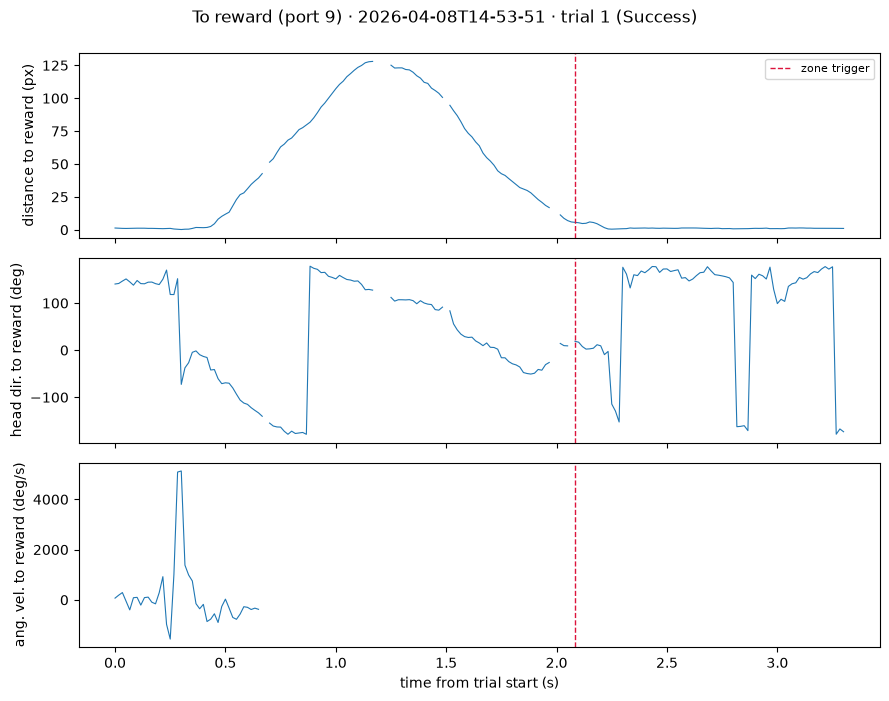

In [4]:
# ---- choose the example trial ----
EXAMPLE_SESSION = list(sessions)[0]
EXAMPLE_TRIAL = 1
# ----------------------------------

row = summary[(summary["session"] == EXAMPLE_SESSION) & (summary["trial_in_session"] == EXAMPLE_TRIAL)].iloc[0]
reward_xy = reward_lookup.get((EXAMPLE_SESSION, int(row["actual_poke"])))
nose, forward = session_head(sessions[EXAMPLE_SESSION]["path"])
s = reward_series(nose, forward, reward_xy, row["outbound_start"], row["inbound_end"])

rel_t = s["time"] - s["time"][0]
t_split = row["inbound_start"] - row["outbound_start"]
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, (y, label) in zip(axes, [(s["dist"], "distance to reward (px)"),
                                 (s["hd"], "head dir. to reward (deg)"),
                                 (s["ahv"], "ang. vel. to reward (deg/s)")]):
    ax.plot(rel_t, y, lw=0.8)
    ax.axvline(t_split, color="crimson", ls="--", lw=1, label="zone trigger")
    ax.set_ylabel(label)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time from trial start (s)")
fig.suptitle(f"To reward (port {int(row['actual_poke'])}) · {EXAMPLE_SESSION} · trial {EXAMPLE_TRIAL} ({row['result']})", y=0.995)
fig.tight_layout()
workspace.save_figure(fig, f"reward_relative_traces_{MOUSE_ID}_{EXAMPLE_SESSION}_t{EXAMPLE_TRIAL}")
plt.show()

## 3 · Per-trial reward-relative summaries

For every trial and segment: mean and final distance to reward, mean absolute head-direction
offset from reward, and mean absolute angular velocity toward reward.

In [5]:
def reward_scalars(series):
    """Reduce a reward_series result to scalar summaries (NaNs if the series is missing)."""
    if series is None:
        return dict(mean_dist=np.nan, final_dist=np.nan, mean_abs_hd=np.nan, mean_abs_ahv=np.nan)
    return dict(
        mean_dist=float(np.nanmean(series["dist"])),
        final_dist=float(series["dist"][-1]),
        mean_abs_hd=float(np.nanmean(np.abs(series["hd"]))),
        mean_abs_ahv=float(np.nanmean(np.abs(series["ahv"]))),
    )


records = []
for key, entry in sessions.items():
    nose, forward = session_head(entry["path"])
    for _, trow in summary[summary["session"] == key].iterrows():
        reward_xy = reward_lookup.get((key, int(trow["actual_poke"])))
        for seg_name, (c0, c1) in SEGMENTS.items():
            sc = reward_scalars(reward_series(nose, forward, reward_xy, trow[c0], trow[c1]))
            records.append({"session": key, "day": trow["day"],
                            "trial_in_session": trow["trial_in_session"], "trial_in_day": trow["trial_in_day"],
                            "result": trow["result"], "segment": seg_name,
                            "reward_port": int(trow["actual_poke"]), **sc})

reward = pd.DataFrame.from_records(records)
n_used = reward["mean_dist"].notna().sum()
print(f"rows: {len(reward)} | with a resolved reward position: {n_used}")
reward.head(9)

rows: 327 | with a resolved reward position: 327


,session,day,trial_in_session,trial_in_day,result,segment,reward_port,mean_dist,final_dist,mean_abs_hd,mean_abs_ahv
0,2026-04-08T14-53-51,Day 11,1,1,Success,whole,9,33.605842,1.041626,112.234812,700.124544
1,2026-04-08T14-53-51,Day 11,1,1,Success,outbound,9,53.724276,5.962338,96.410510,700.124544
2,2026-04-08T14-53-51,Day 11,1,1,Success,inbound,9,1.525095,1.041626,137.254316,513.134051
3,2026-04-08T14-53-51,Day 11,2,2,Success,whole,9,19.531103,1.691569,131.018843,276.430334
4,2026-04-08T14-53-51,Day 11,2,2,Success,outbound,9,20.250220,47.279927,135.209530,276.430334
5,2026-04-08T14-53-51,Day 11,2,2,Success,inbound,9,15.650348,1.691569,108.403581,168.766766
6,2026-04-08T14-53-51,Day 11,3,3,Success,whole,9,24.271781,1.156845,120.739129,203.500342
7,2026-04-08T14-53-51,Day 11,3,3,Success,outbound,9,28.054842,21.312154,125.350388,203.500342
8,2026-04-08T14-53-51,Day 11,3,3,Success,inbound,9,3.386132,1.156845,95.033808,NaN


## 4 · Distributions by outcome (Success / Fail / Miss)

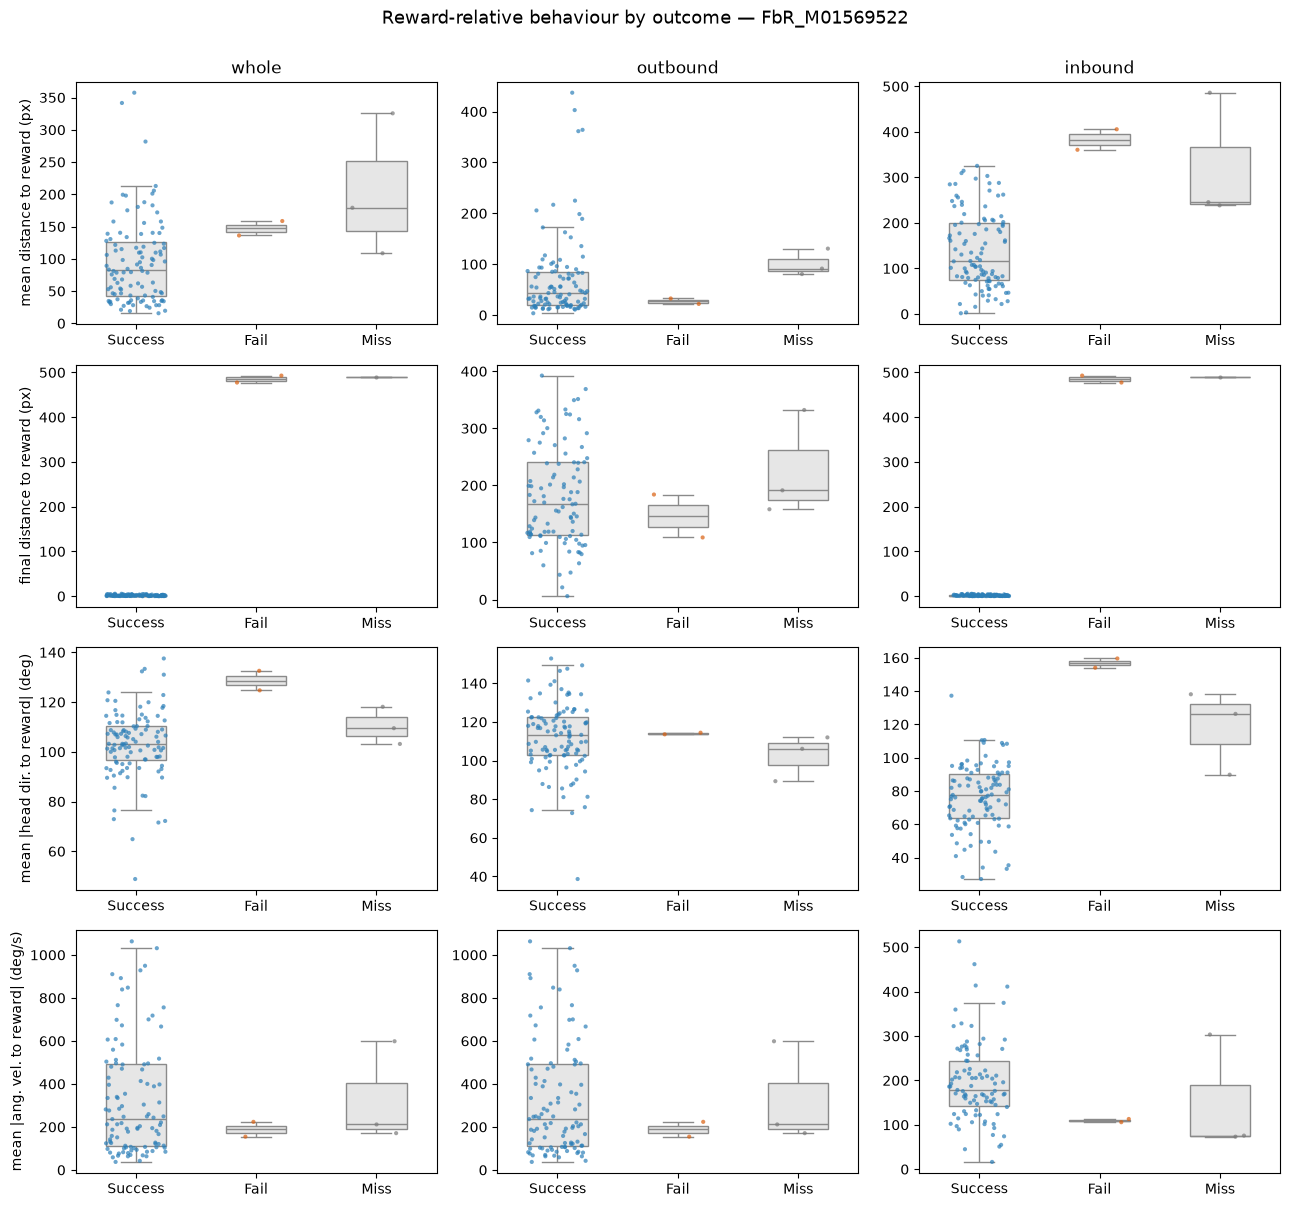

In [6]:
SEG_ORDER = ["whole", "outbound", "inbound"]
RESULT_ORDER = ["Success", "Fail", "Miss"]
PALETTE = {"Success": "#2c7fb8", "Fail": "#d95f0e", "Miss": "#7a7a7a"}


def distribution_grid(df, metric_labels, title, fname):
    """Grid of metric (rows) x segment (cols) distributions, split by outcome (NaN-safe)."""
    fig, axes = plt.subplots(len(metric_labels), len(SEG_ORDER),
                             figsize=(13, 3 * len(metric_labels)), squeeze=False)
    for r, (metric, label) in enumerate(metric_labels.items()):
        for c, seg in enumerate(SEG_ORDER):
            ax = axes[r][c]
            sub = df[df["segment"] == seg].dropna(subset=[metric])
            present = [res for res in RESULT_ORDER if (sub["result"] == res).any()]
            if present:
                sns.boxplot(data=sub, x="result", y=metric, order=present, ax=ax,
                            showfliers=False, width=0.5, color="0.9")
                sns.stripplot(data=sub, x="result", y=metric, order=present, ax=ax,
                              hue="result", palette=PALETTE, legend=False, size=3, jitter=0.25, alpha=0.7)
            ax.set_xlabel("")
            ax.set_ylabel(label if c == 0 else "")
            if r == 0:
                ax.set_title(seg)
    fig.suptitle(title, y=1.002, fontsize=13)
    fig.tight_layout()
    workspace.save_figure(fig, fname)
    plt.show()


METRIC_LABELS = {
    "mean_dist": "mean distance to reward (px)",
    "final_dist": "final distance to reward (px)",
    "mean_abs_hd": "mean |head dir. to reward| (deg)",
    "mean_abs_ahv": "mean |ang. vel. to reward| (deg/s)",
}
distribution_grid(reward, METRIC_LABELS, f"Reward-relative behaviour by outcome — {MOUSE_ID}", f"reward_relative_{MOUSE_ID}")

In [7]:
out_path = workspace.OUTPUT_DIR / f"reward_relative_{MOUSE_ID}.csv"
reward.to_csv(out_path, index=False)
print("saved:", out_path)

saved: /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Pose_Trajectory_Analysis/outputs/reward_relative_FbR_M01569522.csv
